In [ ]:
import tensorflow as tf
from tensorflow import keras
from keras import models
from keras import layers
import numpy as np

# Load dataset
fashion_mnist = tf.keras.datasets.fashion_mnist
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

print("Training data shape:", x_train.shape) # n_sample, h_pixel, w_pixel

Training data shape: (60000, 28, 28)


In [ ]:
# If x_train shape is 3-dimension array ---> Need to convert to 4-D (Batch size, Height, Width, Channel) for Conv2D
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)
print("New shape:", x_train.shape) # n_sample, h_pixel, w_pixel, color channel (depth)

# scaling pixel from 0-255 to 0-1
x_train, x_test = x_train / 255.0, x_test / 255.0

input_shape_val = x_train.shape[1:]
print("Detected Input Shape:", input_shape_val)

New shape: (60000, 28, 28, 1)
Detected Input Shape: (28, 28, 1)


In [ ]:
model = tf.keras.models.Sequential([tf.keras.layers.Flatten(),
                                    tf.keras.layers.Dense(128, activation=tf.nn.relu),
                                    tf.keras.layers.Dense(10, activation=tf.nn.softmax)])

# Add convolutions (the last three lines are the same)
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(64, (3,3), activation='relu', input_shape=input_shape_val), #input_shape=(28,28,1)
                        # asking keras to generate 64 filters.
                        # These filters are 3 by 3. their activation is relu, which means the negative values will be thrown away,
                        # and finally the input shape is as before, the 28 by 28. That extra 1 just means that we are
                        # tallying using a single byte for color depth (because fashion_mnist dataset is gray scale, so it use one byte)
    tf.keras.layers.MaxPooling2D(2,2), # maximum value, 2 by 2 pool, so for every 4 pixels, the biggest one will survive.
    tf.keras.layers.Conv2D(64,(3,3), activation='relu'), # Add another convolution layer
    tf.keras.layers.MaxPooling2D(2,2), # Add another max-pooling layer
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'), # Dense hidden layer with 128 neurons
    tf.keras.layers.Dense(10, activation='softmax'), # Dense output layer with 10 neurons
]) # from above lines the convolutions will filter it to the features that determine the output

model.summary() # allows to inspect the layers of the model, and see the journey of the image through the convolutions

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 26, 26, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 13, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 11, 11, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 243,786 (952.29 KB)

 Trainable params: 243,786 (952.29 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(x_train, y_train, epochs=10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 81s 42ms/step - accuracy: 0.8406 - loss: 0.4399
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 76s 41ms/step - accuracy: 0.8910 - loss: 0.2956
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 81s 40ms/step - accuracy: 0.9087 - loss: 0.2487
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 83s 40ms/step - accuracy: 0.9203 - loss: 0.2151
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 75s 40ms/step - accuracy: 0.9298 - loss: 0.1878
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 75s 40ms/step - accuracy: 0.9383 - loss: 0.1647
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 75s 40ms/step - accuracy: 0.9446 - loss: 0.1452
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 75s 40ms/step - accuracy: 0.9520 - loss: 0.1271
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 75s 40ms/step - accuracy: 0.9578 - loss: 0.1122
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 74s 39ms/step - accuracy: 0.9625 - loss: 0.0980


In [ ]:
test_loss, test_accuracy = model.evaluate(x_test, y_test)
print(f'Test accuracy: {test_accuracy}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9149 - loss: 0.2892
Test accuracy: 0.914900004863739


In [ ]:
predictions = model.predict(x_test)
print(f'Predictions for the first 10 test images: {np.argmax(predictions[:10], axis=1)}')
print(f'Actual labels for the first 10 test images: {y_test[:10]}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step
Predictions for the first 10 test images: [9 2 1 1 6 1 4 6 5 7]
Actual labels for the first 10 test images: [9 2 1 1 6 1 4 6 5 7]


Confusion Matrix:
[[843   2  16   9   1   2 122   0   5   0]
 [  4 988   0   6   0   0   1   0   1   0]
 [ 19   3 872   9  29   0  68   0   0   0]
 [ 15  12  11 913  26   0  19   0   4   0]
 [  0   1  65  14 862   0  57   0   1   0]
 [  0   0   0   0   0 978   0  14   0   8]
 [ 88   4  54  17  49   0 783   0   5   0]
 [  0   0   0   0   0   6   0 977   0  17]
 [  3   1   3   2   2   1   5   2 981   0]
 [  0   0   0   0   0   7   0  41   0 952]]


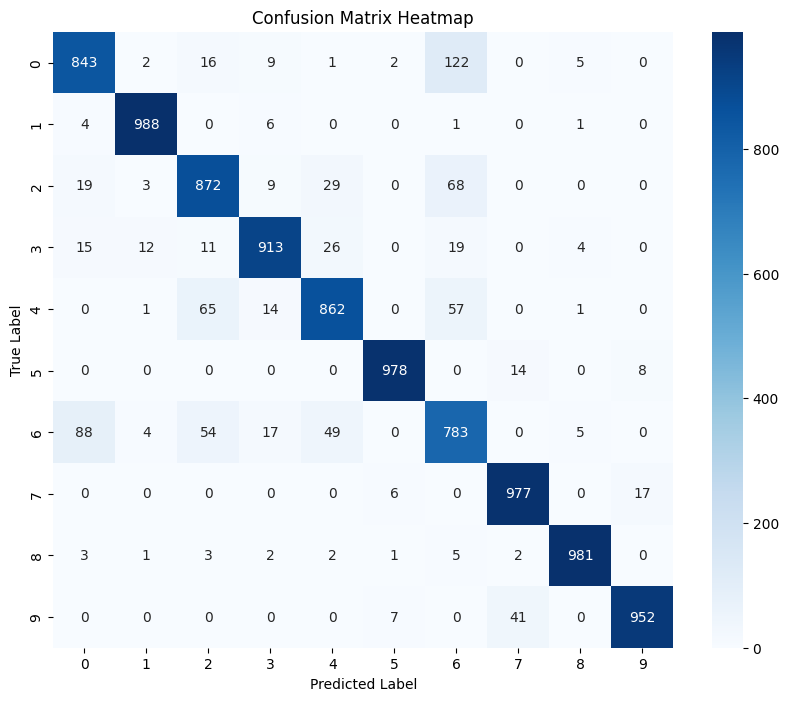

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

predicted_classes = np.argmax(predictions, axis=1)
cm = confusion_matrix(y_test, predicted_classes)
print('Confusion Matrix:')
print(cm)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix Heatmap')
plt.show()

In [ ]:
from sklearn.metrics import classification_report

report = classification_report(y_test, predicted_classes)
print('\nClassification Report:')
print(report)


Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.84      0.85      1000
           1       0.98      0.99      0.98      1000
           2       0.85      0.87      0.86      1000
           3       0.94      0.91      0.93      1000
           4       0.89      0.86      0.88      1000
           5       0.98      0.98      0.98      1000
           6       0.74      0.78      0.76      1000
           7       0.94      0.98      0.96      1000
           8       0.98      0.98      0.98      1000
           9       0.97      0.95      0.96      1000

    accuracy                           0.91     10000
   macro avg       0.92      0.91      0.92     10000
weighted avg       0.92      0.91      0.92     10000



Total misclassified samples: 851


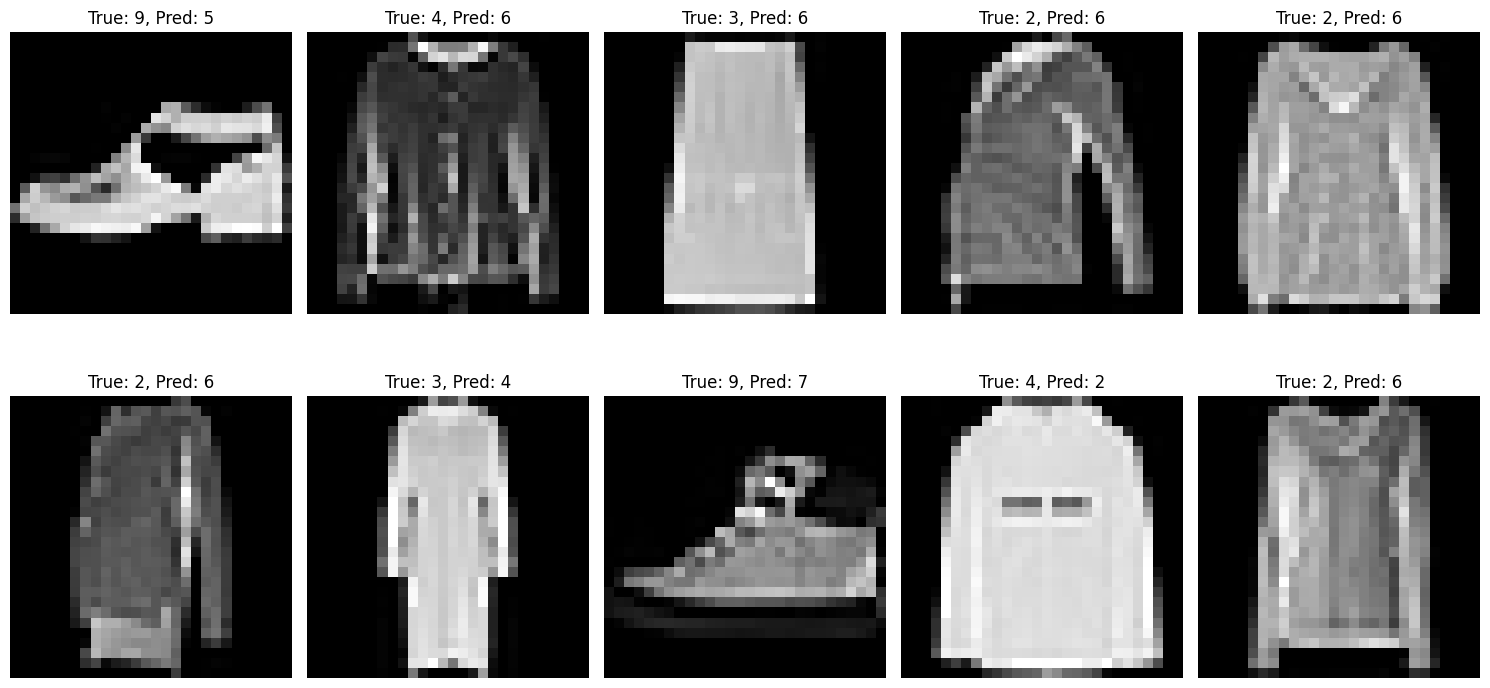

In [ ]:
# Find misclassified samples
misclassified_indices = np.where(predicted_classes != y_test)[0]

print(f'Total misclassified samples: {len(misclassified_indices)}')

# Display a few misclassified samples
num_display = 10  # Number of misclassified samples to display

plt.figure(figsize=(15, 8))
for i, idx in enumerate(misclassified_indices[:num_display]):
    plt.subplot(2, 5, i + 1) # Adjust subplot grid based on num_display
    plt.imshow(x_test[idx].reshape(28, 28), cmap='gray')
    plt.title(f'True: {y_test[idx]}, Pred: {predicted_classes[idx]}')
    plt.axis('off')
plt.tight_layout()
plt.show()